# Testing LPIPS

Here, we test the LPIPS functionality that we have implemented to see does it really represent the semantic distance between two images or not.

In [1]:
import torch
import sys

import sys
from unittest.mock import MagicMock
sys.modules['dysweep'] = MagicMock()
sys.modules['wandb'] = MagicMock()

sys.path.append("..")
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'

In [2]:
from lpips import LPIPS

lpips_kwargs = (
    {
        "pretrained": True,
        "net": "alex",
        "version": "0.1",
        "lpips": True,
        "spatial": False,
        "pnet_rand": False,
        "pnet_tune": False,
        "use_dropout": True,
        "model_path": None,
        "eval_mode": True,
        "verbose": False,
    }
)

perceptual_function = LPIPS(**lpips_kwargs)




/home/ylu217/Desktop/notebook-benchmark/.nb/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ylu217/Desktop/notebook-benchmark/.nb/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


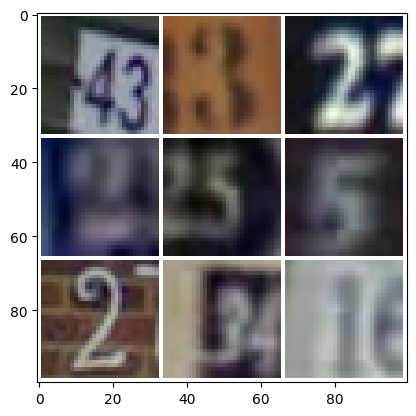

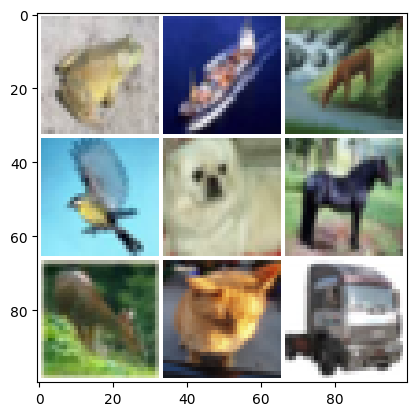

In [3]:
from model_zoo.datasets import get_loaders
from dotenv import load_dotenv
import os
import torchvision
import matplotlib.pyplot as plt

torch.manual_seed(0)

load_dotenv(override=True)
data_root = os.environ.get('DATA_DIR', '../data')

cifar10_loader, _, _ = get_loaders( 'cifar10', data_root=os.environ.get('DATA_DIR', '../data'), device=device, batch_size=9)
svhn_loader, _, _ = get_loaders( 'svhn', data_root=os.environ.get('DATA_DIR', '../data'), device=device, batch_size=9)

svhn_batch = next(iter(svhn_loader))[0]/255
cifar10_batch = next(iter(cifar10_loader))[0]/255

svhn_grid = torchvision.utils.make_grid(svhn_batch, nrow=3, padding=1, pad_value=1)
cifar10_grid = torchvision.utils.make_grid(cifar10_batch, nrow=3, padding=1, pad_value=1)


# plot the images
plt.imshow(svhn_grid.permute(1, 2, 0).cpu().numpy()) 
plt.show()
plt.imshow(cifar10_grid.permute(1, 2, 0).cpu().numpy())
plt.show()

In [4]:
perceptual_function = perceptual_function.to(device)
perceptual_function.forward(svhn_batch, cifar10_batch).flatten()
torch.manual_seed(0)
# reshuffle the svhn batch
for i in range(10):
    svhn_batch_reshuffled = svhn_batch[torch.randperm(svhn_batch.size(0))]
    cifar10_batch_reshuffled = cifar10_batch[torch.randperm(cifar10_batch.size(0))]
    print("SVHN and SVHN", perceptual_function.forward(svhn_batch_reshuffled, svhn_batch).flatten().mean().item())
    print("CIFAR10 and CIFAR10", perceptual_function.forward(cifar10_batch_reshuffled, cifar10_batch).flatten().mean().item())
    print("SVHN and CIFAR10", perceptual_function.forward(cifar10_batch_reshuffled, svhn_batch_reshuffled).flatten().mean().item())
    print("----")

SVHN and SVHN 0.1371045857667923
CIFAR10 and CIFAR10 0.1854601353406906
SVHN and CIFAR10 0.2658296823501587
----
SVHN and SVHN 0.12519212067127228
CIFAR10 and CIFAR10 0.1586257815361023
SVHN and CIFAR10 0.2558830976486206
----
SVHN and SVHN 0.14478938281536102
CIFAR10 and CIFAR10 0.1698179841041565
SVHN and CIFAR10 0.25173595547676086
----
SVHN and SVHN 0.17864634096622467
CIFAR10 and CIFAR10 0.1483881026506424
SVHN and CIFAR10 0.253910630941391
----
SVHN and SVHN 0.1504233032464981
CIFAR10 and CIFAR10 0.1140756756067276
SVHN and CIFAR10 0.2533413767814636
----
SVHN and SVHN 0.1622827649116516
CIFAR10 and CIFAR10 0.14715330302715302
SVHN and CIFAR10 0.24502427875995636
----
SVHN and SVHN 0.1672549992799759
CIFAR10 and CIFAR10 0.13821229338645935
SVHN and CIFAR10 0.2506585717201233
----
SVHN and SVHN 0.16004802286624908
CIFAR10 and CIFAR10 0.14743198454380035
SVHN and CIFAR10 0.2645651400089264
----
SVHN and SVHN 0.15367579460144043
CIFAR10 and CIFAR10 0.1633896827697754
SVHN and CIFAR1

# Test on grayscale images

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 3.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.99MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.29MB/s]
100%|██████████| 26.4M/26.4M [00:05<00:00, 4.89MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 357kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 684kB/s]


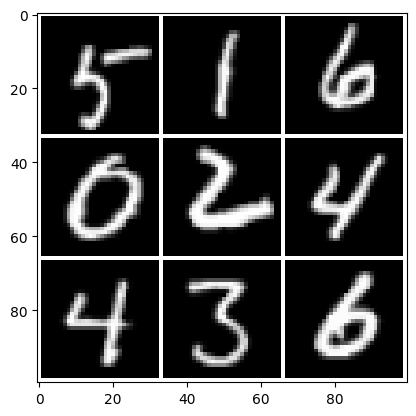

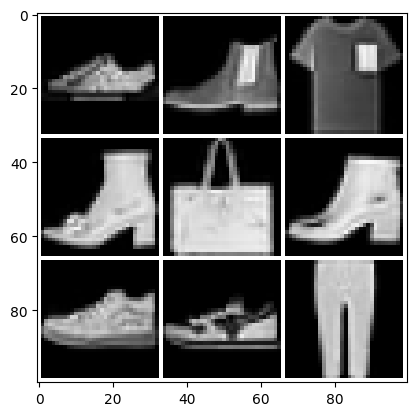

In [5]:
from model_zoo.datasets import get_loaders
from dotenv import load_dotenv
import os
import torchvision
import matplotlib.pyplot as plt


load_dotenv(override=True)
data_root = os.environ.get('DATA_DIR', '../data')
mnist_loader, _, _ = get_loaders( 'mnist', data_root=os.environ.get('DATA_DIR', '../data'), device=device, batch_size=9, additional_dataset_args=dict(resize_image=[32, 32]))
fmnist_loader, _, _ = get_loaders( 'fashion-mnist', data_root=os.environ.get('DATA_DIR', '../data'), device=device, batch_size=9, additional_dataset_args=dict(resize_image=[32, 32]))

mnist_batch = next(iter(mnist_loader))[0]/255
fmnist_batch = next(iter(fmnist_loader))[0]/255

mnist_grid = torchvision.utils.make_grid(mnist_batch, nrow=3, padding=1, pad_value=1)
fmnist_grid = torchvision.utils.make_grid(fmnist_batch, nrow=3, padding=1, pad_value=1)


# plot the images
plt.imshow(mnist_grid.permute(1, 2, 0).cpu().numpy()) 
plt.show()
plt.imshow(fmnist_grid.permute(1, 2, 0).cpu().numpy())
plt.show()


In [6]:
fmnist_batch.shape

torch.Size([9, 1, 32, 32])

In [7]:
perceptual_function = perceptual_function.to(device)
perceptual_function.forward(mnist_batch, fmnist_batch).flatten()
# repeat the first channel of fmnist and mnist batch
# fmnist_batch = fmnist_batch.repeat(1, 1, 1, 3)

torch.manual_seed(0)
# reshuffle the svhn batch
for i in range(10):
    mnist_batch_reshuffled = mnist_batch[torch.randperm(mnist_batch.size(0))]
    fmnist_batch_reshuffled = fmnist_batch[torch.randperm(fmnist_batch.size(0))]
    print("MNIST and MNIST", perceptual_function.forward(mnist_batch_reshuffled, mnist_batch).flatten().mean().item())
    print("FMNIST and FMNIST", perceptual_function.forward(fmnist_batch_reshuffled, fmnist_batch).flatten().mean().item())
    print("MNIST and FMNIST", perceptual_function.forward(fmnist_batch_reshuffled, mnist_batch_reshuffled).flatten().mean().item())
    print("----")

MNIST and MNIST 0.11593164503574371
FMNIST and FMNIST 0.1284881979227066
MNIST and FMNIST 0.16960614919662476
----
MNIST and MNIST 0.0905371904373169
FMNIST and FMNIST 0.14571881294250488
MNIST and FMNIST 0.20290642976760864
----
MNIST and MNIST 0.0928812175989151
FMNIST and FMNIST 0.1657070517539978
MNIST and FMNIST 0.20413462817668915
----
MNIST and MNIST 0.13324075937271118
FMNIST and FMNIST 0.12080490589141846
MNIST and FMNIST 0.19222065806388855
----
MNIST and MNIST 0.121946319937706
FMNIST and FMNIST 0.11866455525159836
MNIST and FMNIST 0.19452479481697083
----
MNIST and MNIST 0.14096027612686157
FMNIST and FMNIST 0.08873999118804932
MNIST and FMNIST 0.1907024085521698
----
MNIST and MNIST 0.13403333723545074
FMNIST and FMNIST 0.1623193621635437
MNIST and FMNIST 0.2087789922952652
----
MNIST and MNIST 0.12721866369247437
FMNIST and FMNIST 0.15386709570884705
MNIST and FMNIST 0.194097101688385
----
MNIST and MNIST 0.12886615097522736
FMNIST and FMNIST 0.14392511546611786
MNIST and